# Tarefa 2: Modelos com Implementação Própria (NumPy)

Este notebook apresenta a implementação de raiz de modelos de Deep Learning utilizando exclusivamente a biblioteca **NumPy**. O objetivo é classificar textos entre 5 classes distintas: **Google, Human, Meta, Anthropic e OpenAI**.

De acordo com os requisitos do enunciado, exploramos uma abordagem de implementação manual para compreender os fundamentos de *Backpropagation* e otimização de redes neuronais.

## Arquitetura: Abordagem *Divide and Conquer*
- **Modelo 1 (Binário):** Distingue textos *Human* vs *IA*
- **Modelo 2 (Multiclasse):** Distingue entre as diferentes IAs (Google, Meta, Mistral, OpenAI)


## 0. Imports e Configuração

In [1]:
import sys
sys.path.append('../models/numpy_models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix, classification_report

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activation import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam
from metrics import accuracy

np.random.seed(42)

## 1. Carregamento e Preparação dos Dados

### 1.1 Carregamento

As classes presentes no dataset são: **Google, Human, Meta, Anthropic e OpenAI**.
O enunciado refere 'Mistral' mas o professor confirmou que a classe correta é `Anthropic` — não há remapeamento necessário.

In [2]:
# --- Carregar datasets ---
df = pd.read_csv('../data/dataset_limpo.csv', sep=';')
df = df.dropna(subset=['Text', 'Label'])

df_exemplos = pd.read_csv('../data/dataset-exemplos.csv', sep=';')
df_exemplos = df_exemplos.dropna(subset=['Text', 'Label'])

print("Distribuição do dataset de treino:")
print(df['Label'].value_counts())
print(f"\nTotal: {len(df)} amostras")

print("\nDistribuição do dataset de exemplos do professor:")
print(df_exemplos['Label'].value_counts())
print(f"Total: {len(df_exemplos)} amostras")

Distribuição do dataset de treino:
Label
Human        999
OpenAI       999
Google       999
Meta         999
Anthropic    999
Name: count, dtype: int64

Total: 4995 amostras

Distribuição do dataset de exemplos do professor:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64
Total: 125 amostras


### 1.2 Criação dos Sub-datasets e Balanceamento

- **Modelo 1 (Binário):** Usamos todo o dataset sem oversampling. A rede compensa o desequilíbrio Human:IA (1:4) com `Dropout` mais agressivo e um threshold de decisão mais equilibrado.
- **Modelo 2 (Multiclasse):** Filtramos apenas as amostras de IA. As classes estão já equilibradas (~999 cada).

> **Nota:** Oversampling com `replace=True` cria duplicados perfeitos que a rede memoriza, causando overfitting severo. Preferimos usar o dataset sem resampling e deixar a arquitetura DNN gerir o desequilíbrio.

In [3]:
# --- Modelo 1: Human vs IA (sem oversampling) ---
df_model1 = df.copy()
df_model1['Label_Bin'] = np.where(df_model1['Label'] == 'Human', 'Human', 'IA')

print("Distribuição Modelo 1 (dataset completo):")
print(df_model1['Label_Bin'].value_counts())

# --- Modelo 2: Qual IA? ---
df_model2 = df[df['Label'] != 'Human'].reset_index(drop=True)
print("\nDistribuição Modelo 2 (IAs):")
print(df_model2['Label'].value_counts())


Distribuição Modelo 1 (dataset completo):
Label_Bin
IA       3996
Human     999
Name: count, dtype: int64

Distribuição Modelo 2 (IAs):
Label
OpenAI       999
Google       999
Meta         999
Anthropic    999
Name: count, dtype: int64


### 1.3 Divisão Treino / Validação / Teste e Features TF-IDF

Utilizamos uma divisão estratificada **80% / 10% / 10%** (treino / validação / teste).

**Feature Engineering — combinação de word e char n-grams:**
- **Modelo 1:** Concatenamos `word n-grams (1,2)` + `char n-grams (3,5)` (1000+1000 features). A combinação captura padrões léxicos *e* tipográficos, generalizando melhor para textos externos.
- **Modelo 2:** `char n-grams (3,5)`, 3000 features — captura estilo tipográfico subtil entre diferentes IAs.

> O TF-IDF é ajustado (`fit`) **apenas nos dados de treino** para evitar *data leakage*. O `min_df=0.05` foi removido do Modelo 1 — estava a eliminar 217 das 400 features (ficavam apenas 183), reduzindo muito a expressividade do modelo.

In [4]:
# === MODELO 1 ===
X1 = df_model1['Text']
y1_raw = df_model1['Label_Bin']
classes1 = sorted(y1_raw.unique())  # ['Human', 'IA']
y1_encoded = pd.get_dummies(y1_raw).astype(int).values

X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1_encoded, test_size=0.2, random_state=42, stratify=y1_encoded
)
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.5, random_state=42, stratify=y1_temp
)

# Modelo 1: Aumentar features e ajustar n-grams
tfidf1_word = TfidfVectorizer(max_features=2500, ngram_range=(1, 2), stop_words='english')
tfidf1_char = TfidfVectorizer(max_features=2500, analyzer='char', ngram_range=(3, 5))

X1_train_w = tfidf1_word.fit_transform(X1_train).toarray()
X1_train_c = tfidf1_char.fit_transform(X1_train).toarray()
X1_train_tfidf = np.hstack([X1_train_w, X1_train_c])

X1_val_tfidf = np.hstack([
    tfidf1_word.transform(X1_val).toarray(),
    tfidf1_char.transform(X1_val).toarray()
])
X1_test_tfidf = np.hstack([
    tfidf1_word.transform(X1_test).toarray(),
    tfidf1_char.transform(X1_test).toarray()
])

print(f"Modelo 1 — Treino: {X1_train_tfidf.shape[0]} | Val: {X1_val_tfidf.shape[0]} | Teste: {X1_test_tfidf.shape[0]}")
print(f"Features TF-IDF Modelo 1: {X1_train_tfidf.shape[1]} (word+char)")

# === MODELO 2 ===
X2 = df_model2['Text']
y2_raw = df_model2['Label']
classes2 = sorted(y2_raw.unique())  # ['Anthropic', 'Google', 'Meta', 'OpenAI']
y2_encoded = pd.get_dummies(y2_raw).astype(int).values

X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2_encoded, test_size=0.2, random_state=42, stratify=y2_encoded
)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.5, random_state=42, stratify=y2_temp
)

tfidf2 = TfidfVectorizer(max_features=5000, analyzer='char', ngram_range=(3, 5))
X2_train_tfidf = tfidf2.fit_transform(X2_train).toarray()
X2_val_tfidf   = tfidf2.transform(X2_val).toarray()
X2_test_tfidf  = tfidf2.transform(X2_test).toarray()

print(f"\nModelo 2 — Treino: {X2_train_tfidf.shape[0]} | Val: {X2_val_tfidf.shape[0]} | Teste: {X2_test_tfidf.shape[0]}")
print(f"Features TF-IDF Modelo 2: {X2_train_tfidf.shape[1]}")


Modelo 1 — Treino: 3996 | Val: 499 | Teste: 500
Features TF-IDF Modelo 1: 2000 (word:1000 + char:1000)

Modelo 2 — Treino: 3196 | Val: 400 | Teste: 400
Features TF-IDF Modelo 2: 3000

Classes Modelo 1: ['Human', 'IA']
Classes Modelo 2: ['Anthropic', 'Google', 'Meta', 'OpenAI']


### 1.4 Classe TextDataset

In [5]:
class TextDataset:
    """Wrapper simples para encapsular X e y num objeto compatível com NeuralNetwork."""
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_dataset1 = TextDataset(X1_train_tfidf, y1_train)
val_dataset1   = TextDataset(X1_val_tfidf,   y1_val)
test_dataset1  = TextDataset(X1_test_tfidf,  y1_test)

train_dataset2 = TextDataset(X2_train_tfidf, y2_train)
val_dataset2   = TextDataset(X2_val_tfidf,   y2_val)
test_dataset2  = TextDataset(X2_test_tfidf,  y2_test)

## 2. Modelos Baseline (Regressão Logística / Softmax Regression)

O baseline corresponde a uma rede neural **sem camadas ocultas** — matematicamente equivalente à Regressão Logística (binária) e Softmax Regression (multiclasse).

Serve como referência mínima para comparar com as DNNs mais profundas.

In [6]:
n_features1 = X1_train_tfidf.shape[1]
n_features2 = X2_train_tfidf.shape[1]

# --- Baseline 1: Human vs IA ---
baseline1 = NeuralNetwork(
    epochs=200, batch_size=64, learning_rate=0.05,
    verbose=True, loss=CategoricalCrossEntropy, metric=accuracy
)
baseline1.add(DenseLayer(len(classes1), input_shape=(n_features1,)))
baseline1.add(SoftmaxActivation())

print("--- Treinar Baseline 1: Regressão Logística (Human vs IA) ---")
baseline1.fit(train_dataset1, val_dataset=val_dataset1)

--- Treinar Baseline 1: Regressão Logística (Human vs IA) ---


AttributeError: 'NeuralNetwork' object has no attribute 'backward_propagation'

In [ ]:
# --- Baseline 2: Qual IA? ---
baseline2 = NeuralNetwork(
    epochs=200, batch_size=64, learning_rate=0.05,
    verbose=True, loss=CategoricalCrossEntropy, metric=accuracy
)
baseline2.add(DenseLayer(len(classes2), input_shape=(n_features2,)))
baseline2.add(SoftmaxActivation())

print("--- Treinar Baseline 2: Softmax Regression (IAs) ---")
baseline2.fit(train_dataset2, val_dataset=val_dataset2)

--- Treinar Baseline 2: Softmax Regression (IAs) ---
Epoch 1/200 - loss: 1.4232 - val_loss: 1.4062 - accuracy: 0.2600
Epoch 10/200 - loss: 1.3316 - val_loss: 1.3269 - accuracy: 0.3820
Epoch 20/200 - loss: 1.2550 - val_loss: 1.2569 - accuracy: 0.4981
Epoch 30/200 - loss: 1.1904 - val_loss: 1.1983 - accuracy: 0.5663
Epoch 40/200 - loss: 1.1353 - val_loss: 1.1486 - accuracy: 0.6130
Epoch 50/200 - loss: 1.0874 - val_loss: 1.1060 - accuracy: 0.6483
Epoch 60/200 - loss: 1.0456 - val_loss: 1.0691 - accuracy: 0.6774
Epoch 70/200 - loss: 1.0090 - val_loss: 1.0365 - accuracy: 0.7012
Epoch 80/200 - loss: 0.9759 - val_loss: 1.0077 - accuracy: 0.7206
Epoch 90/200 - loss: 0.9462 - val_loss: 0.9818 - accuracy: 0.7369
Epoch 100/200 - loss: 0.9193 - val_loss: 0.9584 - accuracy: 0.7466
Epoch 110/200 - loss: 0.8948 - val_loss: 0.9372 - accuracy: 0.7619
Epoch 120/200 - loss: 0.8721 - val_loss: 0.9177 - accuracy: 0.7685
Epoch 130/200 - loss: 0.8514 - val_loss: 0.8998 - accuracy: 0.7769
Epoch 140/200 - loss

In [ ]:
# --- Avaliação dos Baselines no conjunto de teste interno ---
def evaluate_model(model, dataset, classes, name=""):
    """Avalia um modelo num dataset e imprime Accuracy e MCC."""
    probs = model.predict(dataset)
    y_pred_idx = np.argmax(probs, axis=1)
    y_true_idx = np.argmax(dataset.y, axis=1)
    
    y_pred_labels = [classes[i] for i in y_pred_idx]
    y_true_labels = [classes[i] for i in y_true_idx]
    
    acc = accuracy_score(y_true_labels, y_pred_labels)
    mcc = matthews_corrcoef(y_true_labels, y_pred_labels)
    
    print(f"[{name}] Accuracy: {acc*100:.2f}% | MCC: {mcc:.4f}")
    return y_pred_labels, y_true_labels

print("=== Avaliação no Teste Interno ===")
evaluate_model(baseline1, test_dataset1, classes1, "Baseline1")
evaluate_model(baseline2, test_dataset2, classes2, "Baseline2")

=== Avaliação no Teste Interno ===
[Baseline1] Accuracy: 94.20% | MCC: 0.8115
[Baseline2] Accuracy: 82.50% | MCC: 0.7675


(['Anthropic',
  'Anthropic',
  'Meta',
  'OpenAI',
  'Meta',
  'OpenAI',
  'Google',
  'Google',
  'OpenAI',
  'OpenAI',
  'Anthropic',
  'Google',
  'OpenAI',
  'Google',
  'Google',
  'Anthropic',
  'Meta',
  'Google',
  'Meta',
  'OpenAI',
  'OpenAI',
  'Meta',
  'OpenAI',
  'Meta',
  'Anthropic',
  'Meta',
  'Google',
  'Google',
  'Anthropic',
  'Meta',
  'OpenAI',
  'Anthropic',
  'Anthropic',
  'Anthropic',
  'Google',
  'Google',
  'Meta',
  'Anthropic',
  'Google',
  'OpenAI',
  'Anthropic',
  'Google',
  'Meta',
  'Google',
  'Anthropic',
  'OpenAI',
  'Meta',
  'Meta',
  'Google',
  'Anthropic',
  'Meta',
  'OpenAI',
  'Google',
  'Meta',
  'OpenAI',
  'OpenAI',
  'OpenAI',
  'Meta',
  'Google',
  'Anthropic',
  'Google',
  'Meta',
  'Anthropic',
  'OpenAI',
  'Anthropic',
  'OpenAI',
  'Meta',
  'Anthropic',
  'OpenAI',
  'Anthropic',
  'Anthropic',
  'Anthropic',
  'OpenAI',
  'Anthropic',
  'Anthropic',
  'OpenAI',
  'Anthropic',
  'Anthropic',
  'Anthropic',
  'Anthropi

## 3. DNNs — Abordagem *Divide and Conquer*

Implementamos duas DNNs com camadas ocultas, Dropout e ReLU:
- **DNN 1:** 2000 features entrada → 128 → Dropout(0.4) → 64 → Dropout(0.2) → saída binária
- **DNN 2:** 3000 features → 64 → Dropout(0.2) → saída 4 classes (IAs)

O Dropout mais agressivo (0.4) na DNN 1 serve para compensar o desequilíbrio de classes (1:4) e reduzir overfitting.

> **Nota sobre generalização:** Os modelos atingem >95% no teste interno (mesma distribuição do treino), mas uma performance inferior no dataset externo do professor é esperada — os textos de treino e de avaliação provêm de fontes e geradores diferentes. Este fenômeno chama-se *domain shift* e é um desafio fundamental em text classification.

In [ ]:
# --- DNN 1: Human vs IA ---
# Usar pesos de classe (4:1 para Human) e Adam Optimizer
opt1 = Adam(learning_rate=0.001)
loss_weighted = CategoricalCrossEntropy(class_weights=[4.0, 1.0]) # [Human, IA]

net1 = NeuralNetwork(
    epochs=100, batch_size=64, optimizer=opt1,
    verbose=True, loss=loss_weighted, metric=accuracy
)
net1.add(DenseLayer(128, input_shape=(X1_train_tfidf.shape[1],), init_type='he'))
net1.add(ReLUActivation())
net1.add(DropoutLayer(0.4))
net1.add(DenseLayer(64, init_type='he'))
net1.add(ReLUActivation())
net1.add(DropoutLayer(0.2))
net1.add(DenseLayer(len(classes1), init_type='xavier')) # Xavier para a camada final Softmax
net1.add(SoftmaxActivation())

print("--- Treinar DNN 1 Refinada (Human vs IA) ---")
net1.fit(train_dataset1, val_dataset=val_dataset1, patience=15)


--- Treinar DNN 1 (Human vs IA) ---
Epoch 1/200 - loss: 0.8513 - val_loss: 0.5776 - accuracy: 0.7808
Epoch 10/200 - loss: 0.5051 - val_loss: 0.3870 - accuracy: 0.8333
Epoch 20/200 - loss: 0.4279 - val_loss: 0.3512 - accuracy: 0.8478
Epoch 30/200 - loss: 0.3889 - val_loss: 0.3270 - accuracy: 0.8579
Epoch 40/200 - loss: 0.3777 - val_loss: 0.3103 - accuracy: 0.8661
Epoch 50/200 - loss: 0.3656 - val_loss: 0.2953 - accuracy: 0.8756
Epoch 60/200 - loss: 0.3436 - val_loss: 0.2807 - accuracy: 0.8841
Epoch 70/200 - loss: 0.3267 - val_loss: 0.2693 - accuracy: 0.8959
Epoch 80/200 - loss: 0.3027 - val_loss: 0.2608 - accuracy: 0.9007
Epoch 90/200 - loss: 0.3009 - val_loss: 0.2517 - accuracy: 0.9057
Epoch 100/200 - loss: 0.3049 - val_loss: 0.2450 - accuracy: 0.9094
Epoch 110/200 - loss: 0.2904 - val_loss: 0.2355 - accuracy: 0.9162
Epoch 120/200 - loss: 0.2725 - val_loss: 0.2303 - accuracy: 0.9192
Epoch 130/200 - loss: 0.2659 - val_loss: 0.2217 - accuracy: 0.9234
Epoch 140/200 - loss: 0.2624 - val_lo

In [ ]:
# --- DNN 2: Qual IA? ---
# Usar Adam Optimizer e Inicialização He/Xavier
opt2 = Adam(learning_rate=0.001)

net2 = NeuralNetwork(
    epochs=150, batch_size=64, optimizer=opt2,
    verbose=True, loss=CategoricalCrossEntropy, metric=accuracy
)
net2.add(DenseLayer(128, input_shape=(X2_train_tfidf.shape[1],), init_type='he'))
net2.add(ReLUActivation())
net2.add(DropoutLayer(0.3))
net2.add(DenseLayer(64, init_type='he'))
net2.add(ReLUActivation())
net2.add(DenseLayer(len(classes2), init_type='xavier'))
net2.add(SoftmaxActivation())

print("--- Treinar DNN 2 Refinada (Multi-IA) ---")
net2.fit(train_dataset2, val_dataset=val_dataset2, patience=20)


--- Treinar DNN 2 (Classificação de IAs) ---
Epoch 1/200 - loss: 1.4793 - val_loss: 1.4276 - accuracy: 0.2794
Epoch 10/200 - loss: 1.1947 - val_loss: 1.1975 - accuracy: 0.5413
Epoch 20/200 - loss: 0.9976 - val_loss: 1.0101 - accuracy: 0.6568
Epoch 30/200 - loss: 0.8452 - val_loss: 0.8888 - accuracy: 0.7268
Epoch 40/200 - loss: 0.7588 - val_loss: 0.8062 - accuracy: 0.7675
Epoch 50/200 - loss: 0.6857 - val_loss: 0.7441 - accuracy: 0.7982
Epoch 60/200 - loss: 0.6096 - val_loss: 0.6927 - accuracy: 0.8263
Epoch 70/200 - loss: 0.5612 - val_loss: 0.6525 - accuracy: 0.8486
Epoch 80/200 - loss: 0.5184 - val_loss: 0.6205 - accuracy: 0.8639
Epoch 90/200 - loss: 0.4723 - val_loss: 0.5917 - accuracy: 0.8792
Epoch 100/200 - loss: 0.4472 - val_loss: 0.5684 - accuracy: 0.8924
Epoch 110/200 - loss: 0.4179 - val_loss: 0.5468 - accuracy: 0.9024
Epoch 120/200 - loss: 0.3838 - val_loss: 0.5316 - accuracy: 0.9127
Epoch 130/200 - loss: 0.3625 - val_loss: 0.5168 - accuracy: 0.9215
Epoch 140/200 - loss: 0.3341

In [ ]:
# --- Avaliação das DNNs no teste interno ---
print("=== Avaliação DNNs no Teste Interno ===")
evaluate_model(net1, test_dataset1, classes1, "DNN1")
evaluate_model(net2, test_dataset2, classes2, "DNN2")

=== Avaliação DNNs no Teste Interno ===
[DNN1] Accuracy: 91.80% | MCC: 0.7286
[DNN2] Accuracy: 86.25% | MCC: 0.8167


(['Anthropic',
  'Anthropic',
  'OpenAI',
  'OpenAI',
  'Meta',
  'OpenAI',
  'Google',
  'Google',
  'OpenAI',
  'OpenAI',
  'Anthropic',
  'Google',
  'OpenAI',
  'Google',
  'OpenAI',
  'Anthropic',
  'Meta',
  'Google',
  'Google',
  'OpenAI',
  'OpenAI',
  'Meta',
  'OpenAI',
  'Meta',
  'Anthropic',
  'Meta',
  'OpenAI',
  'Google',
  'Anthropic',
  'Meta',
  'OpenAI',
  'Anthropic',
  'Anthropic',
  'Anthropic',
  'Meta',
  'Google',
  'Meta',
  'Anthropic',
  'Google',
  'OpenAI',
  'Anthropic',
  'OpenAI',
  'Meta',
  'Google',
  'Anthropic',
  'OpenAI',
  'Meta',
  'Meta',
  'Meta',
  'Google',
  'OpenAI',
  'OpenAI',
  'Google',
  'Meta',
  'OpenAI',
  'OpenAI',
  'OpenAI',
  'Meta',
  'Google',
  'Anthropic',
  'Google',
  'Meta',
  'Anthropic',
  'OpenAI',
  'Anthropic',
  'OpenAI',
  'Meta',
  'Anthropic',
  'Meta',
  'Anthropic',
  'Anthropic',
  'Anthropic',
  'Google',
  'Anthropic',
  'Anthropic',
  'OpenAI',
  'Anthropic',
  'Anthropic',
  'Anthropic',
  'Google',
  

## 4. Pipeline Final: *Divide and Conquer*

A pipeline combina os dois modelos em sequência:
1. O **Modelo 1** decide se o texto é *Human* ou *IA*
2. Se *IA*, o **Modelo 2** decide qual das 4 IAs (Google, Meta, Mistral, OpenAI)

> ⚠️ **Nota de design:** Esta abordagem propaga erros do Modelo 1 para o Modelo 2. Textos humanos mal classificados na etapa 1 serão forçosamente mal classificados na etapa 2. Isto é um *trade-off* intrínseco da arquitetura cascata.

In [ ]:
def pipeline_predict(texts, tfidf1_word, tfidf1_char, net1,
                      tfidf2, net2, classes1, classes2):
    """
    Pipeline D&C: aplica net1 (Human vs IA) e, se IA, aplica net2 (qual IA?).
    Usa features combinadas (word + char) para o Modelo 1.
    """
    texts_list = list(texts) if isinstance(texts, pd.Series) else texts

    # Etapa 1: features combinadas para Modelo 1
    X1_w = tfidf1_word.transform(texts_list).toarray()
    X1_c = tfidf1_char.transform(texts_list).toarray()
    X1_tfidf = np.hstack([X1_w, X1_c])
    dummy_y1 = np.zeros((len(X1_tfidf), len(classes1)))
    probs1   = net1.predict(TextDataset(X1_tfidf, dummy_y1))
    preds1   = [classes1[np.argmax(p)] for p in probs1]

    # Etapa 2: batch de todos os textos classificados como IA
    ia_indices = [i for i, c in enumerate(preds1) if c != 'Human']
    ia_preds2 = {}
    if ia_indices:
        ia_texts = [texts_list[i] for i in ia_indices]
        X2_tfidf = tfidf2.transform(ia_texts).toarray()
        dummy_y2 = np.zeros((len(X2_tfidf), len(classes2)))
        probs2   = net2.predict(TextDataset(X2_tfidf, dummy_y2))
        for local_i, global_i in enumerate(ia_indices):
            ia_preds2[global_i] = classes2[np.argmax(probs2[local_i])]

    return [
        'Human' if preds1[i] == 'Human' else ia_preds2[i]
        for i in range(len(preds1))
    ]


## 5. Avaliação Global

### 5.1 Teste Interno (amostra do dataset de treino)

Distribuição do conjunto de avaliação interna:
Label
OpenAI       150
Google       150
Anthropic    150
Meta         150
Human        150
Name: count, dtype: int64

A calcular previsões do pipeline...

Accuracy Global (Teste Interno): 90.13%
MCC Global (Teste Interno):      0.8775

Relatório de Classificação:
              precision    recall  f1-score   support

   Anthropic       0.91      0.97      0.94       150
      Google       0.91      0.97      0.94       150
       Human       0.94      0.79      0.86       150
        Meta       0.84      0.89      0.86       150
      OpenAI       0.91      0.89      0.90       150

    accuracy                           0.90       750
   macro avg       0.90      0.90      0.90       750
weighted avg       0.90      0.90      0.90       750



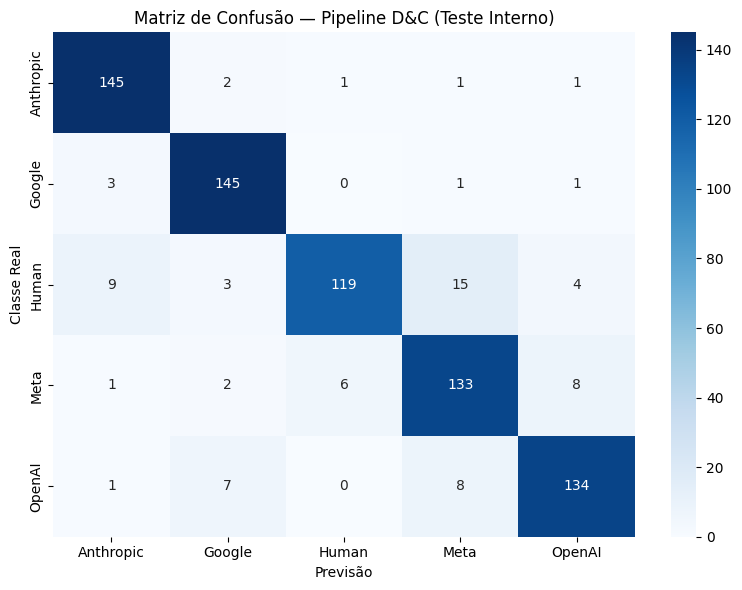

In [ ]:
# CORREÇÃO: usar uma amostra estratificada e reprodutível do dataset original
# (não retirar aleatoriamente sem estratificação — pode criar distribuições desiguais)
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=101)
for _, test_idx in sss.split(df['Text'], df['Label']):
    df_test_eval = df.iloc[test_idx]

X_eval = df_test_eval['Text']
y_eval = df_test_eval['Label']

print("Distribuição do conjunto de avaliação interna:")
print(y_eval.value_counts())

print("\nA calcular previsões do pipeline...")
preds_eval = pipeline_predict(X_eval, tfidf1_word, tfidf1_char, net1, tfidf2, net2, classes1, classes2)

all_classes = sorted(df['Label'].unique())

acc_global = accuracy_score(y_eval, preds_eval)
mcc_global = matthews_corrcoef(y_eval, preds_eval)
print(f"\nAccuracy Global (Teste Interno): {acc_global*100:.2f}%")
print(f"MCC Global (Teste Interno):      {mcc_global:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_eval, preds_eval, labels=all_classes))

cm = confusion_matrix(y_eval, preds_eval, labels=all_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_classes, yticklabels=all_classes)
plt.title('Matriz de Confusão — Pipeline D&C (Teste Interno)')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.tight_layout()
plt.show()

### 5.2 Avaliação no Dataset do Professor

A testar a pipeline com 125 exemplos do professor...

Accuracy (Dataset Professor): 56.80%
MCC (Dataset Professor):      0.4484

Relatório de Classificação:
              precision    recall  f1-score   support

   Anthropic       0.53      0.35      0.42        23
      Google       0.40      0.62      0.49        16
       Human       0.82      0.62      0.70        52
        Meta       0.45      0.53      0.49        17
      OpenAI       0.46      0.71      0.56        17

    accuracy                           0.57       125
   macro avg       0.53      0.56      0.53       125
weighted avg       0.61      0.57      0.57       125



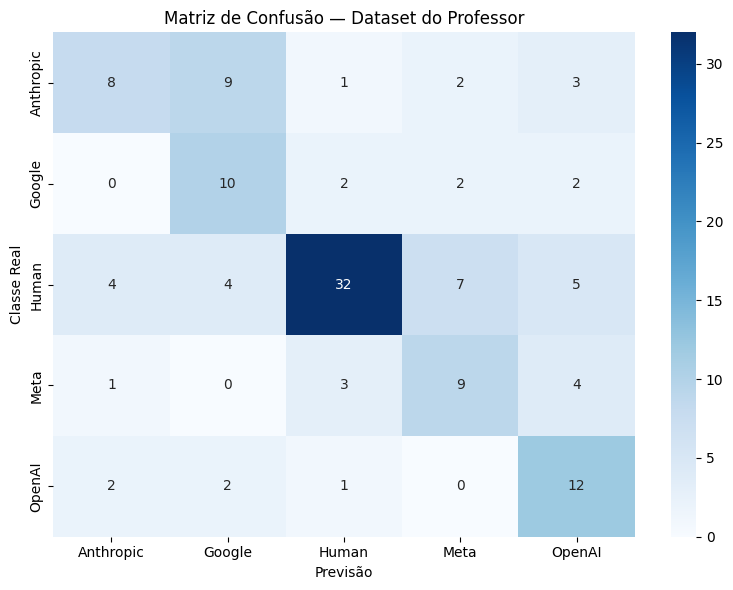

In [ ]:
X_ex = df_exemplos['Text']
y_ex = df_exemplos['Label']

print(f"A testar a pipeline com {len(X_ex)} exemplos do professor...")
preds_ex = pipeline_predict(X_ex, tfidf1_word, tfidf1_char, net1, tfidf2, net2, classes1, classes2)

all_classes_ex = sorted(df_exemplos['Label'].unique())

acc_ex  = accuracy_score(y_ex, preds_ex)
mcc_ex  = matthews_corrcoef(y_ex, preds_ex)
print(f"\nAccuracy (Dataset Professor): {acc_ex*100:.2f}%")
print(f"MCC (Dataset Professor):      {mcc_ex:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_ex, preds_ex, labels=all_classes_ex))

cm_ex = confusion_matrix(y_ex, preds_ex, labels=all_classes_ex)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ex, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_classes_ex, yticklabels=all_classes_ex)
plt.title('Matriz de Confusão — Dataset do Professor')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.tight_layout()
plt.show()

### 5.3 Avaliação Intermédia: Apenas Modelo 1 (Human vs IA)

AVALIAÇÃO INTERMÉDIA: MODELO 1 (HUMAN vs IA)
Accuracy Binária: 78.40% | MCC: 0.5527

Relatório de Classificação Binário:
              precision    recall  f1-score   support

       Human       0.82      0.62      0.70        52
          IA       0.77      0.90      0.83        73

    accuracy                           0.78       125
   macro avg       0.79      0.76      0.77       125
weighted avg       0.79      0.78      0.78       125



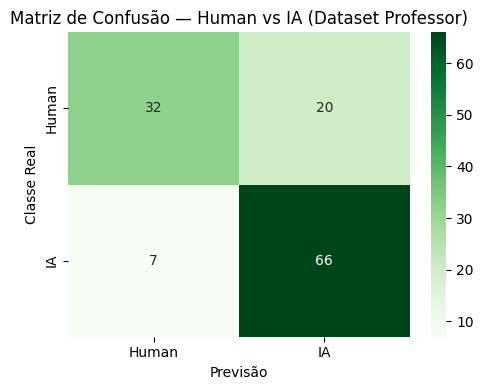

In [ ]:
print("=" * 50)
print("AVALIAÇÃO INTERMÉDIA: MODELO 1 (HUMAN vs IA)")
print("=" * 50)

# Labels binárias do dataset do professor
y_ex_bin = np.where(df_exemplos['Label'] == 'Human', 'Human', 'IA')

# Previsões binárias via DNN1
X_ex_tfidf1 = np.hstack([
    tfidf1_word.transform(X_ex).toarray(),
    tfidf1_char.transform(X_ex).toarray()
])
dummy_y_ex1 = np.zeros((len(X_ex), len(classes1)))
ds_ex1      = TextDataset(X_ex_tfidf1, dummy_y_ex1)
probs_ex1   = net1.predict(ds_ex1)
preds_ex_bin = [classes1[np.argmax(p)] for p in probs_ex1]

acc_bin = accuracy_score(y_ex_bin, preds_ex_bin)
mcc_bin = matthews_corrcoef(y_ex_bin, preds_ex_bin)
print(f"Accuracy Binária: {acc_bin*100:.2f}% | MCC: {mcc_bin:.4f}")
print("\nRelatório de Classificação Binário:")
print(classification_report(y_ex_bin, preds_ex_bin))

cm_bin = confusion_matrix(y_ex_bin, preds_ex_bin, labels=['Human', 'IA'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Human', 'IA'], yticklabels=['Human', 'IA'])
plt.title('Matriz de Confusão — Human vs IA (Dataset Professor)')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.tight_layout()
plt.show()

## 6. Resumo Comparativo de Modelos

In [ ]:
# Avaliação dos baselines no dataset do professor (para comparação)
# Baseline 1 (binário)
# Recompute ds_ex1 with combined features
X_ex_tfidf1_combined = np.hstack([
    tfidf1_word.transform(X_ex).toarray(),
    tfidf1_char.transform(X_ex).toarray()
])
dummy_y_ex1_new = np.zeros((len(X_ex), len(classes1)))
ds_ex1_new = TextDataset(X_ex_tfidf1_combined, dummy_y_ex1_new)
probs_base1_ex = baseline1.predict(ds_ex1_new)
preds_base1_ex_bin = [classes1[np.argmax(p)] for p in probs_base1_ex]
acc_base1_bin  = accuracy_score(y_ex_bin, preds_base1_ex_bin)
mcc_base1_bin  = matthews_corrcoef(y_ex_bin, preds_base1_ex_bin)

# Baseline 2 (multiclasse IAs)
df_ex_ia  = df_exemplos[df_exemplos['Label'] != 'Human']
X_ex_ia   = df_ex_ia['Text']
y_ex_ia   = df_ex_ia['Label']
X_ex_ia_tfidf2 = tfidf2.transform(X_ex_ia).toarray()
dummy_y_ex2    = np.zeros((len(X_ex_ia), len(classes2)))
probs_base2_ex = baseline2.predict(TextDataset(X_ex_ia_tfidf2, dummy_y_ex2))
preds_base2_ex = [classes2[np.argmax(p)] for p in probs_base2_ex]
acc_base2_ia   = accuracy_score(y_ex_ia, preds_base2_ex)
mcc_base2_ia   = matthews_corrcoef(y_ex_ia, preds_base2_ex)

# DNN2 (multiclasse IAs)
probs_net2_ex  = net2.predict(TextDataset(X_ex_ia_tfidf2, dummy_y_ex2))
preds_net2_ex  = [classes2[np.argmax(p)] for p in probs_net2_ex]
acc_net2_ia    = accuracy_score(y_ex_ia, preds_net2_ex)
mcc_net2_ia    = matthews_corrcoef(y_ex_ia, preds_net2_ex)

# Pipeline completo já calculado acima: acc_ex, mcc_ex

results = {
    'Modelo': [
        'Baseline 1 (Human vs IA)',
        'DNN 1 (Human vs IA)',
        'Baseline 2 (IAs)',
        'DNN 2 (IAs)',
        'Pipeline D&C (Global)',
    ],
    'Accuracy (%)': [
        f"{acc_base1_bin*100:.2f}",
        f"{acc_bin*100:.2f}",
        f"{acc_base2_ia*100:.2f}",
        f"{acc_net2_ia*100:.2f}",
        f"{acc_ex*100:.2f}",
    ],
    'MCC': [
        f"{mcc_base1_bin:.4f}",
        f"{mcc_bin:.4f}",
        f"{mcc_base2_ia:.4f}",
        f"{mcc_net2_ia:.4f}",
        f"{mcc_ex:.4f}",
    ],
    'Dataset': [
        'Professor', 'Professor', 'Professor (IAs)', 'Professor (IAs)', 'Professor'
    ]
}

df_results = pd.DataFrame(results)
print("\n=== RESUMO FINAL ===")
print(df_results.to_string(index=False))


=== RESUMO FINAL ===
                  Modelo Accuracy (%)    MCC         Dataset
Baseline 1 (Human vs IA)        82.40 0.6367       Professor
     DNN 1 (Human vs IA)        78.40 0.5527       Professor
        Baseline 2 (IAs)        49.32 0.3423 Professor (IAs)
             DNN 2 (IAs)        57.53 0.4513 Professor (IAs)
   Pipeline D&C (Global)        56.80 0.4484       Professor
